In [25]:
import pandas as pd

In [26]:
data = pd.read_csv('../data/processed/demand_timeseries.csv')
data.head()

,Unnamed: 0,Date,StockCode,Quantity
0,0,2009-12-01,15036,55.0
1,1,2009-12-02,15036,0.0
2,2,2009-12-03,15036,240.0
3,3,2009-12-04,15036,12.0
4,4,2009-12-05,15036,12.0


In [27]:
data.drop('Unnamed: 0', inplace = True, axis = 1)

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18700 entries, 0 to 18699
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       18700 non-null  object 
 1   StockCode  18700 non-null  object 
 2   Quantity   18700 non-null  float64
dtypes: float64(1), object(2)
memory usage: 438.4+ KB


##### Picking Representative Product

This so we could do some Stationarity Testing
- Augmented Dickey-Fuller (ADF) Test.
- Seasonal Decomposition (STL)
- Establishing Baselines

In [29]:
top_prod = data.groupby('StockCode')['Quantity'].sum().reset_index()
top_prod = top_prod.sort_values(by = 'Quantity', ascending = False)

rep_prod = top_prod.iloc[0]['StockCode']
top_quant = top_prod.iloc[0]['Quantity']

print(f'Top-selling product: {rep_prod} with {top_quant} units')

Top-selling product: 21212 with 53548.549999999996 units


In [30]:
data_21212 = data[data['StockCode'] == '21212'].copy()
data_21212.head()

,Date,StockCode,Quantity
3366,2009-12-01,21212,294.00
3367,2009-12-02,21212,510.45
3368,2009-12-03,21212,182.00
3369,2009-12-04,21212,193.00
3370,2009-12-05,21212,48.00


In [31]:
data_21212['Date'] = pd.to_datetime(data_21212['Date'])
data_21212 = data_21212.set_index('Date')

data_21212 = data_21212['Quantity'].resample('D').sum()
data_21212 = data_21212.fillna(0)

data_21212.index.freq = 'D'
data_21212.head()

Date
2009-12-01    294.00
2009-12-02    510.45
2009-12-03    182.00
2009-12-04    193.00
2009-12-05     48.00
Freq: D, Name: Quantity, dtype: float64

##### Stationarity Testing (The ADF Test)

We want to use Augmented Dickey-Fuller (ADF) test to check for a "unit root". By this we are checking if the series wanders off (random walk) or if it reverts to a constant mean.

In [32]:
from statsmodels.tsa.stattools import adfuller

In [33]:
def adf_test(series):
    res = adfuller(series, autolag = 'AIC')

    labels = ['ADF Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used']
    for value, label in zip(res, labels):
        print(f'{label} : {value}')
    
    if res[1] <= 0.05:
        print('Data is stationary. Reject the null hypothesis.')
    else:
        print('Data is non-stationary. Fail to reject the null hypothesis.')

adf_test(data_21212)

ADF Test Statistic : -5.4527407206138605
p-value : 2.6222532958047537e-06
#Lags Used : 12
Number of Observations Used : 361
Data is stationary. Reject the null hypothesis.


From the ADF test on StockCode 21212 we found that `p < 0.05`. So we get that the statistic structure is stable, so we can go to the next step.

##### Seasonal Decomposition (STL)

We want to break the "noisy" sales line into three distinct components: Trend, Seasonality, and Residual (Noise).

<Figure size 1200x800 with 0 Axes>

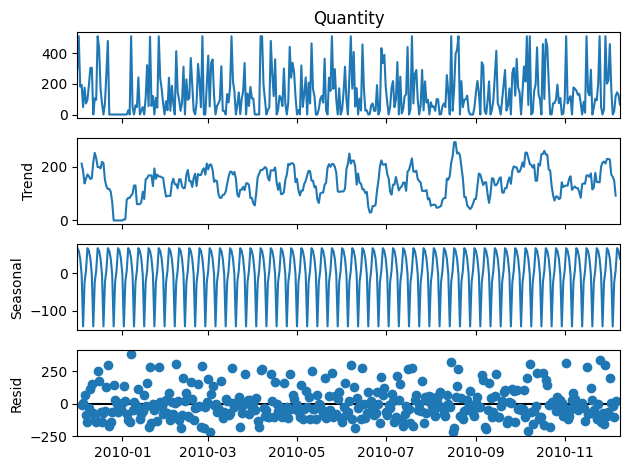

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(data_21212, model = 'additive', period = 7)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize = (12, 8))
decomposition.plot()
plt.show()

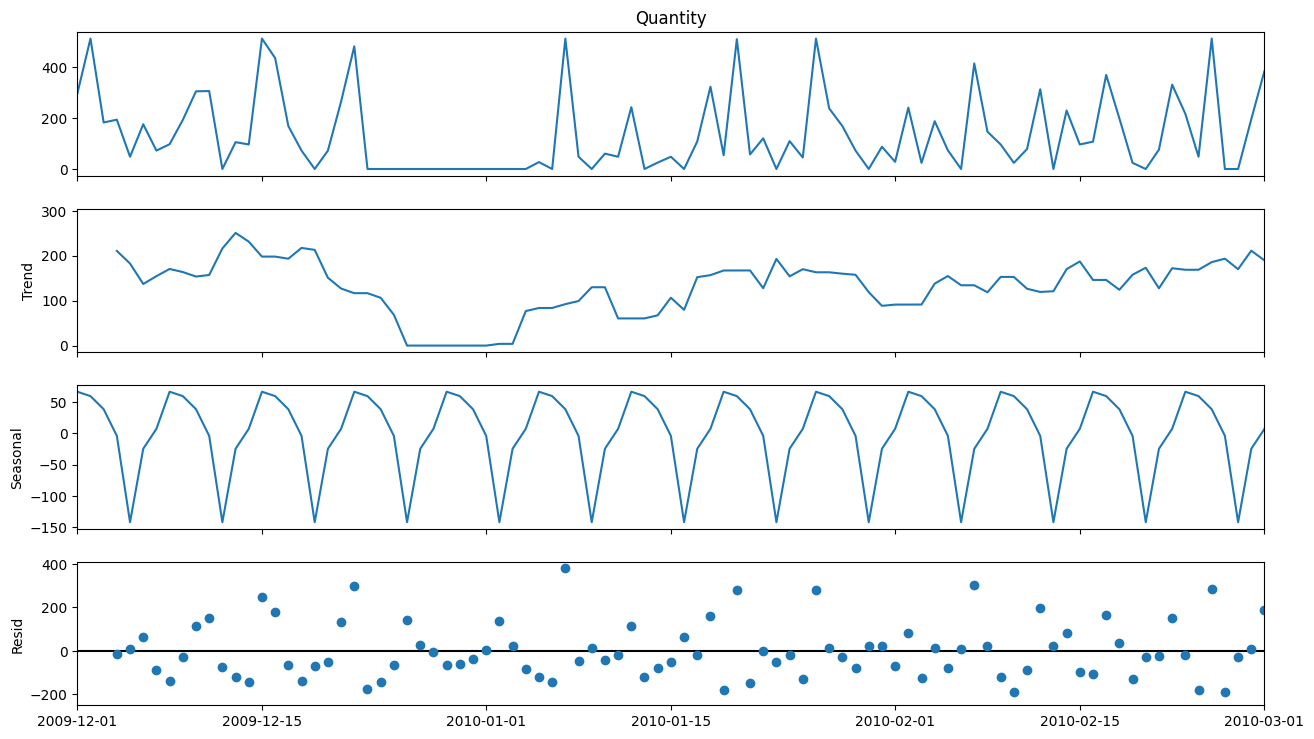

In [40]:
decomposition = seasonal_decompose(data_21212, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(14, 8)

start_date = pd.to_datetime('2009-12-01')
end_date   = pd.to_datetime('2010-03-01')

for ax in fig.axes:
    ax.set_xlim(start_date, end_date)

plt.show()

From above visualization we only need to focus on `Trend`, `Seasonal`, `Resid`. <p>

- Trend "Cyclical Resilience/ Cyclical Component". <p>
    We could see that after the first drop, the trend line never hits zero. This means that the product has a "Base Demand", where the baseline is ~100 units.<p>
    We can maintain a safety stock at least 100 units at all times, as the trend shows 100 units as the floor.
- Seasonal "The Hearthbeat".<p>
    Because `Seasonal` plot is a perfect, repeating wave, this could confirms that the "Day of the Week" is one of Strongest predictors.<p>
    When zooming in we can find that the peak is on `Wednesday` and gradually drops toward sunday, so we should focus on timing rather than just volume. Where we could replenish the stock before Wednesday, maybe on Tuesday. So that products are available at the highest-demand point, and after Wednesday stock levels can be reduced to avoid unnecessary holding costs as demand weakens through the weekend.
- Resid "Anomaly Detection".<p>
    The points jumping to 250-400 are Exogenous Shocks, so this can be likely Bulk Orders or Flash Sales. This could confuse the model with the High Variance, we could clip these outliers or add a "Promotion" flag so the model wjy it jappends.

##### Find the Seasonality Score

Because we cannot just claim the seasonality without the math behind it so we get this

In [ ]:
import numpy as np

resid_var = np.nanvar(residual)
seasonal_resid_var = np.nanvar(seasonal + residual)

seasonality_strength = max(0, 1 - (resid_var / seasonal_resid_var))
print(f"{seasonality_strength:.4f}")

0.2318


After getting the value of `0.2318` we can say that the product highly effected by time.

##### Establishing Baselines

Before going into complex Neural Network (DeepAR), we want to prove that a simple model can't do this prediction. Because if simple average is as accurate as a Transformer, the Transformer is a waste of resource.

Two Baselines:
- Naive Forecast: Predict that tommorow's demand will be exactly the same as today's
- Moving Average (MA): Predict that tommorow's demand will be the average of the last 7 days.

Metrics:
- MAE: To see the Average Error in units (example: "On average, we are off by 5 items")
- RMSE: Penalizes large errors more heavily (example: "To penalize when understocking can be very expensive")

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
df = data.copy()
df.head()

,Date,StockCode,Quantity
0,2009-12-01,15036,55.0
1,2009-12-02,15036,0.0
2,2009-12-03,15036,240.0
3,2009-12-04,15036,12.0
4,2009-12-05,15036,12.0


In [47]:
# Naive Forecast (shift by 1)
df['naive_pred'] = df.groupby('StockCode')['Quantity'].shift(1)

# Moving Average (Mean of last 7 days)
df['ma7_pred'] = df.groupby('StockCode')['Quantity'].shift(1).rolling(window = 7).mean()

df_clean = df.dropna()
df_clean.head()

,Date,StockCode,Quantity,naive_pred,ma7_pred
7,2009-12-08,15036,24.0,60.0,54.142857
8,2009-12-09,15036,0.0,24.0,49.714286
9,2009-12-10,15036,0.0,0.0,49.714286
10,2009-12-11,15036,0.0,0.0,15.428571
11,2009-12-12,15036,0.0,0.0,13.714286


In [48]:
# Extract actuals and predictions for scoring
actual = df_clean['Quantity']
p_naive = df_clean['naive_pred']
p_ma7 = df_clean['ma7_pred']

In [49]:
def eval_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {model_name} ---")
    print(f"MAE (Avg error in units): {mae:.2f}")
    print(f"RMSE (Penalty for big misses): {rmse:.2f}\n")

eval_model(actual, p_naive, "Naive Baseline")
eval_model(actual, p_ma7, "Moving Average Baseline")

--- Naive Baseline ---
MAE (Avg error in units): 50.43
RMSE (Penalty for big misses): 93.80

--- Moving Average Baseline ---
MAE (Avg error in units): 42.76
RMSE (Penalty for big misses): 72.52



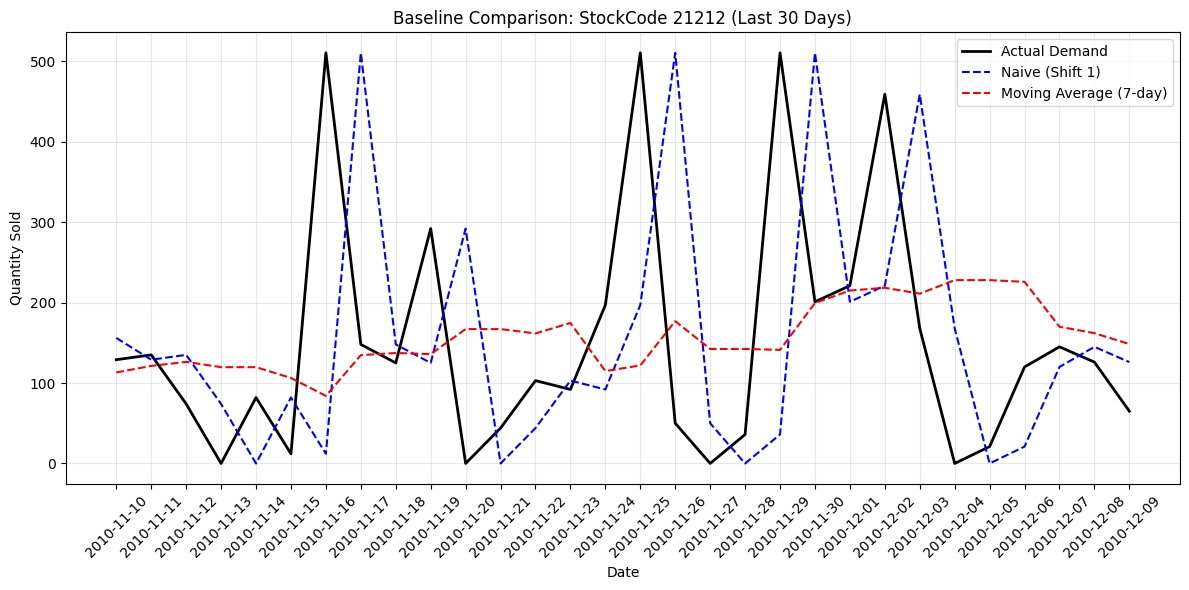

In [51]:
import matplotlib.pyplot as plt

# 1. Filter for the specific product
product_id = '21212'
product_df = df_clean[df_clean['StockCode'] == product_id].tail(30)

# 2. Plotting
plt.figure(figsize=(12, 6))
plt.plot(product_df['Date'], product_df['Quantity'], label='Actual Demand', color='black', linewidth=2)
plt.plot(product_df['Date'], product_df['naive_pred'], label='Naive (Shift 1)', linestyle='--', color='blue')
plt.plot(product_df['Date'], product_df['ma7_pred'], label='Moving Average (7-day)', linestyle='--', color='red')

plt.title(f'Baseline Comparison: StockCode {product_id} (Last 30 Days)')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
# Metrics for StockCode 21212 only
item_actual = product_df['Quantity']
item_naive = product_df['naive_pred']
item_ma7 = product_df['ma7_pred']

print(f"--- Metrics for StockCode {product_id} ---")
print(f"Naive MAE: {mean_absolute_error(item_actual, item_naive):.2f}")
print(f"MA7 MAE:   {mean_absolute_error(item_actual, item_ma7):.2f}")

--- Metrics for StockCode 21212 ---
Naive MAE: 148.92
MA7 MAE:   118.84
